In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
# path = '/home/rfit/Telescope_Array/phd_work/src/BERT/augmentation_research/runs_tr_VAE_ITERATE'
# path = '/home/rfit/Telescope_Array/phd_work/src/BERT/augmentation_research/runs_tr_VAE_V8_ITERATE'
path = '/home/rfit/Telescope_Array/phd_work/src/BERT/augmentation_research/small_decoder_VAE_ITERATE'
all_emb = {}
for part in os.listdir(path):
    all_emb[part] = {}
    for f in os.listdir(path + '/' + part):
        file = path + '/' + part + '/' + f
        n = f.split('_')[-1].replace('.npy', '')
        n=int(n)
        all_emb[part][n] = np.load(file)

In [3]:
diff__pr = all_emb['proton'][8] - all_emb['proton'][0]
diff__ph = all_emb['photon'][8] - all_emb['photon'][0]
mean_pr = np.abs(diff__pr).mean(axis=1)
mean_ph = np.abs(diff__ph).mean(axis=1)

mse_pr = np.power(diff__pr, 2).mean(axis=1)
mse_ph = np.power(diff__ph, 2).mean(axis=1)

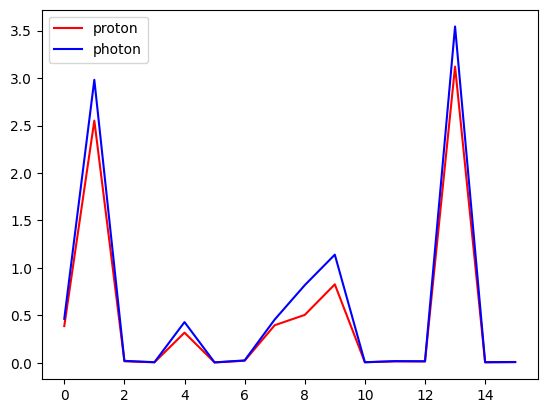

In [4]:
plt.plot(np.abs(diff__pr).mean(axis=0), 'r', label='proton')
plt.plot(np.abs(diff__ph).mean(axis=0), 'b', label='photon')
plt.legend()
plt.show()

In [5]:
import sys
sys.path.append('/home/rfit/Telescope_Array/phd_work/')
sys.path.append('/home/rfit/Telescope_Array/phd_work/src/BERT')
print(sys.path)
import pandas as pd
from src.BERT.pipline import PiplineMask
import torch
from src.train_VAE.model import Encoder, Encoder_Transformer_AE, Encoder_Transformer, DecoderTransformer, VAE
import os
import numpy as np
from tqdm import tqdm
import shutil 
print(os.getenv('CUDA_VISIBAL_DEVICE'))

['/home/rfit/miniconda3/envs/python39/lib/python39.zip', '/home/rfit/miniconda3/envs/python39/lib/python3.9', '/home/rfit/miniconda3/envs/python39/lib/python3.9/lib-dynload', '', '/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages', '/home/rfit/Telescope_Array/phd_work/', '/home/rfit/Telescope_Array/phd_work/src/BERT']
Using device: cuda


2025-12-09 18:56:40.056694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765295800.100820   37491 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765295800.119405   37491 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765295800.174513   37491 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765295800.174548   37491 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765295800.174550   37491 computation_placer.cc:177] computation placer alr

None


In [6]:
embading_path = '/home/rfit/Telescope_Array/phd_work/Models/AutoEncoder/small_decoder_VAE_V10/best'
bert_path:str = '/home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_one_work/best'
pipline_BERT = PiplineMask('/home/rfit/Telescope_Array/phd_work/src/BERT/config.yaml')
pipline_BERT.model.load(bert_path)
VAE_state_dict = torch.load(embading_path)
encoder_model = Encoder_Transformer(6,128, 16,
                    stop_token = pipline_BERT.config['stop_token'],
                    padding_value=pipline_BERT.config['padding_value'])
embading_state_dict = {}
for k,v in VAE_state_dict.items():
    if 'encoder' in k:
        newk = k.replace('encoder.', '')
        # for transformer
        if 'last_' in k:
            newk = newk.replace('last_', 'last_encoder.')
        embading_state_dict[newk] = v
print(embading_state_dict.keys())
print(encoder_model.state_dict().keys())
encoder_model.load_state_dict(embading_state_dict)
encoder_model.to('cuda:0')
encoder_model.eval()
start_token = pipline_BERT.config['start_token']
decoder_model = DecoderTransformer(16,128, 6,
                    num_layers = 2,
                    start_token = start_token,
                    stop_token = pipline_BERT.config['stop_token'],
                    padding_value=pipline_BERT.config['padding_value'],
                    reconstruction_params = [3,4,5])

decoder_state_dict = {}
for k,v in VAE_state_dict.items():
    if 'decoder' in k:
        newk = k.replace('decoder.', '')
        # for transformer
        if 'last_' in k:
            newk = newk.replace('last_', 'last_encoder.')
        decoder_state_dict[newk] = v
decoder_model.load_state_dict(decoder_state_dict)
decoder_model.to('cuda:0')
decoder_model.eval()
particles = ['proton', 'photon']

['catboost_info', 'runs_tr_ITERATE', 'runs_tr_MEAN', 'small_decoder_VAE_ITERATE', 'runs_tr_VAE_MEAN', 'Notebook_emd.ipynb', 'runs_tr_VAE_ITERATE', 'small_decoder_VAE_V9ITERATE', 'runs_tr2', 'loss_hist.png', 'runs_tr_AEITERATE', 'runs_tr_VAE_V8_ITERATE', 'runs', 'runs_tr', 'loss_hist_Augmentation.png', 'runs_tr2_MEAN', 'Check_chanales.ipynb', 'runs_tr_VAE_V8_MEAN', 'runs_tr_VAE_contITERATE', 'runs_tr_contITERATE', 'makeDF.py']
Saving Path: /home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_one_work_hard
6 64 16 6
load model /home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_one_work/best
dict_keys(['embading.weight', 'embading.bias', 'TransformerEncoderLayer.self_attn.in_proj_weight', 'TransformerEncoderLayer.self_attn.in_proj_bias', 'TransformerEncoderLayer.self_attn.out_proj.weight', 'TransformerEncoderLayer.self_attn.out_proj.bias', 'TransformerEncoderLayer.linear1.weight', 'TransformerEncoderLayer.linear1.bias', 'TransformerEncoderLayer.linear2.weight', 'TransformerEncoderLayer.

In [7]:
# def clean_mask(data: torch.Tensor, tokens: Optional[Tuple[int, int, int]] =None, lenght: Optional[int]=None) -> torch.Tensor:
#     """
#     This function cleans a masked tensor by removing start, end, and mask tokens, and adjusting the length accordingly.

#     Parameters:
#     - data (torch.Tensor): The input tensor to be cleaned. It should be of shape (sequence_length, features).
#     - tokens (Optional[Tuple[int, int, int]]): A tuple containing the start token, end token, and mask token. If None, default values will be used.

#     Returns:
#     torch.Tensor: The cleaned tensor with the start, end, and mask tokens removed, and the length adjusted accordingly.
#     """
#     if lenght is not None:
#         return data[:lenght], lenght
#     st, fn, ms = tokens
#     mask = torch.where(data != ms, 1, 0)
#     lenght = torch.sum(mask[:,0]) # length but used st and fn tokens
#     if fn is not None:
#         lenght-=1 # fn token is not real data
#     if st is not None:
#         data = data[1:] # del first data
#         lenght-=1
#     return data[:lenght], lenght  
# def show_pred(data, fake, tokens) -> plt.figure:
#     '''
#     data - shape (det, featches)

#     fake - shape (det, featches)

#     return: fig
#     '''

#     #TODO переписать нормально
#     data, real_lenght = clean_mask(data, tokens = tokens)
#     if lenght_predict is not None:
#         fake_lenght = float(lenght_predict)
#         if tokens[0] is not None:
#             # have start token
#             fake = fake[1:]
#         fake, _ = clean_mask(fake, tokens = tokens, lenght=real_lenght)
#     else:
#         if tokens[0] is not None:
#             # have start token
#             fake = fake[1:]
#         fake, fake_lenght = clean_mask(fake, tokens = tokens, lenght=real_lenght)
#     names = ['det x', 'det y', 'det z', 'signal', 'flat front', '(real - front)']
#     fig, axs = plt.subplots(2,3, figsize = (10,10))
#     for i in range(6):
#         row = i%2
#         col = i//2
#         axs[row][col].plot(fake.to('cpu').detach().numpy()[:,i], 'r')
#         axs[row][col].plot(data.to('cpu').detach().numpy()[:,i], 'b')
#         axs[row][col].legend(['fake', 'true'])
#         axs[row][col].set_title(f'chanal {names[i]}')
#         axs
#     lenght_info = f'real_lenght {real_lenght}\nfake_lenght {fake_lenght}'
#     plt.suptitle(lenght_info)
#     return fig
def show_data(data, fig_axs = None):
    names = ['det x', 'det y', 'det z', 'signal', 'flat front', '(real - front)']    
    if fig_axs is None:
        fig, axs = plt.subplots(2,3, figsize = (10,10))
    else:
        fig, axs = fig_axs
    for i in range(6):
        row = i%2
        col = i//2
        # axs[row][col].plot(fake.to('cpu').detach().numpy()[:,i], 'r')
        axs[row][col].plot(data.to('cpu').detach().numpy()[:,i], 'b')
        axs[row][col].legend(['fake', 'true'])
        axs[row][col].set_title(f'chanal {names[i]}')
        axs
    return fig, axs

In [17]:
def change_dims(data, dims:int, change_range = (-1,1), seq_len = 100):
    results = []
    emb,_,(_,_) = encoder_model(data)
    # Клонируем исходный emb, чтобы не изменять его in-place
    emb_base = emb.clone().detach()
    # Извлекаем координаты из исходных данных (первые 3 канала: det x, det y, det z)
    x_coordinat = data[:,:,:3]
    for step in torch.arange(change_range[0], change_range[1], 0.1):
        # Создаем новый тензор для каждой итерации
        emb_modified = emb_base.clone()
        emb_modified[:,dims] += step
        # Передаем координаты из исходных данных в декодер
        dec, (_,_), num, recon_pred = decoder_model(emb_modified, seq_len, x_coordinat)
        results.append(dec)
    return results



In [19]:
dl_n = 0
pbar = tqdm(pipline_BERT.val_loaders[dl_n])
n=0
particle = particles[dl_n]
for x, _, _ in pbar:
    x = x.to('cuda:0')
    # Правильная распаковка: encoder_model возвращает mu, log_var, (h_n, c_n)
    emb, _, (_, _) = encoder_model(x)
    break

  0%|          | 0/7791 [00:00<?, ?it/s]


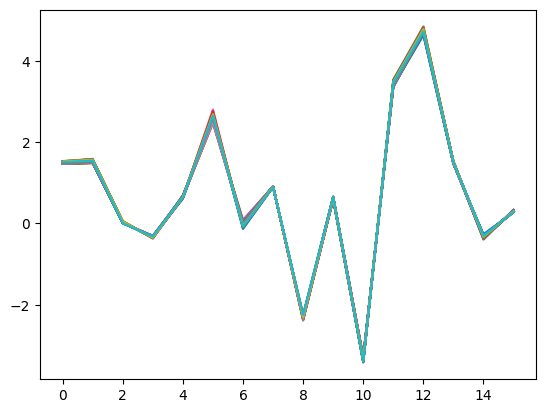

In [20]:
for e in emb:
    plt.plot(e.cpu().detach().numpy())
    plt.grid()

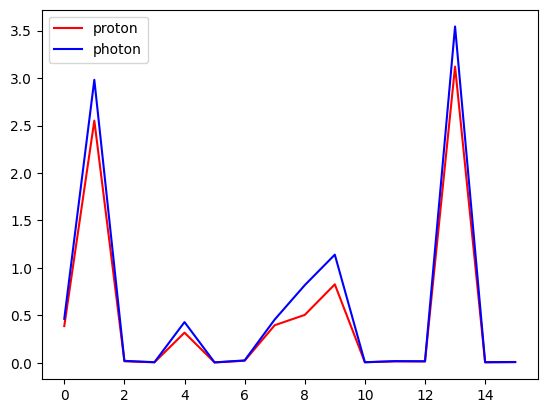

In [21]:
plt.plot(np.abs(diff__pr).mean(axis=0), 'r', label='proton')
plt.plot(np.abs(diff__ph).mean(axis=0), 'b', label='photon')
plt.legend()
plt.show()

(<Figure size 1000x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'chanal det x'}>,
         <Axes: title={'center': 'chanal det z'}>,
         <Axes: title={'center': 'chanal flat front'}>],
        [<Axes: title={'center': 'chanal det y'}>,
         <Axes: title={'center': 'chanal signal'}>,
         <Axes: title={'center': 'chanal (real - front)'}>]], dtype=object))

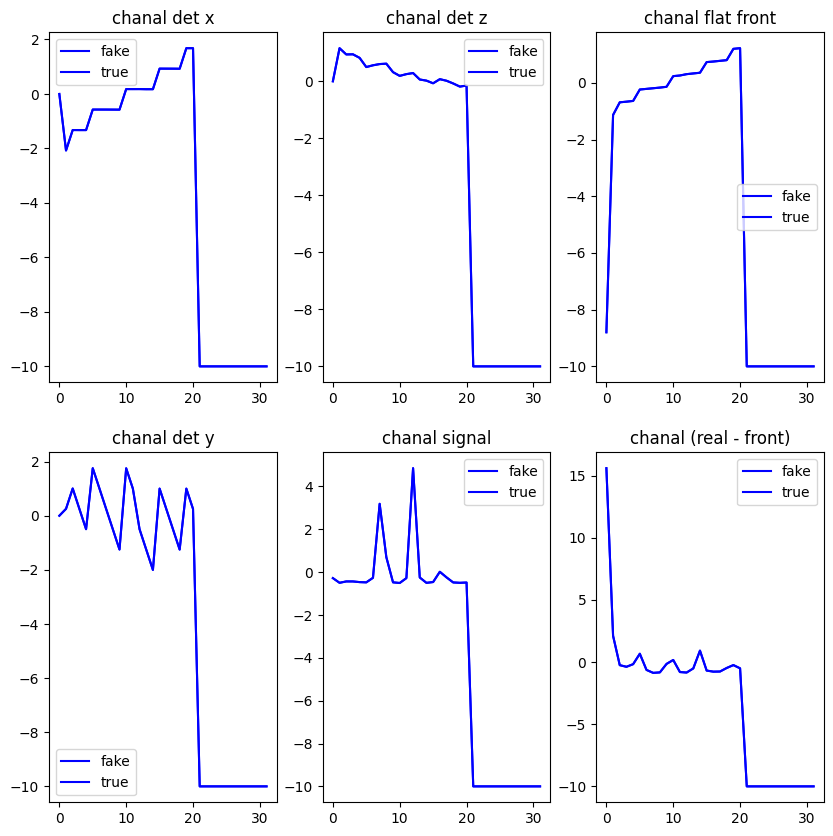

In [22]:
fig, axs = show_data(x[1])
show_data(x[1], (fig, axs))

In [23]:
def show_data_many(data, results, fig_axs = None, lenght =10):
    names = ['det x', 'det y', 'det z', 'signal', 'flat front', '(real - front)']    
    if fig_axs is None:
        fig, axs = plt.subplots(2,3, figsize = (30,30))
    else:
        fig, axs = fig_axs
    legend = []
    for j in range(len(results)):
        for i in range(6):
            row = i%2
            col = i//2
            # axs[row][col].plot(fake.to('cpu').detach().numpy()[:,i], 'r')
            axs[row][col].plot(results[j].to('cpu').detach().numpy()[1:lenght,i],)
            # axs[row][col].legend([f'fake {i}'])
            # axs[row][col].set_title(f'chanal {names[i]}')
        legend.append(f'fake {j}')
    legend.append('true')
    for i in range(6):
        row = i%2
        col = i//2
        # axs[row][col].plot(fake.to('cpu').detach().numpy()[:,i], 'r')
        axs[row][col].plot(data.to('cpu').detach().numpy()[1:lenght,i], 'b')
        # axs[row][col].legend(['true'])
        axs[row][col].set_title(f'chanal {names[i]}')
        axs[row][col].legend(legend)
    return fig, axs

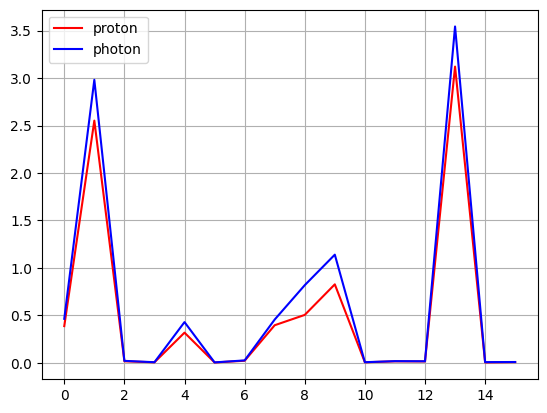

In [24]:
plt.plot(np.abs(diff__pr).mean(axis=0), 'r', label='proton')
plt.plot(np.abs(diff__ph).mean(axis=0), 'b', label='photon')
plt.legend()
plt.grid()
plt.show()

In [25]:
for j in range(16):
    i=60
    results = change_dims(x[i:i+1], j)
    np_res = np.array([r.cpu().detach().numpy() for r in results])
    np_res = np_res[:,0,:,:]
    print(f'{j} ch std:', np_res.std(axis=0).mean())
# show_data_many(x[i], [r[0] for r in results],lenght=18)

0 ch std: 0.0010963127
1 ch std: 0.00075206195
2 ch std: 0.0012095231
3 ch std: 0.0012764793
4 ch std: 0.0007907197
5 ch std: 0.10667236
6 ch std: 0.0368424
7 ch std: 0.0006406681
8 ch std: 0.18326935
9 ch std: 0.08986704
10 ch std: 0.09305973
11 ch std: 0.15248469
12 ch std: 0.028265445
13 ch std: 0.0006971157
14 ch std: 0.0018625025
15 ch std: 0.0013058832


(<Figure size 3000x3000 with 6 Axes>,
 array([[<Axes: title={'center': 'chanal det x'}>,
         <Axes: title={'center': 'chanal det z'}>,
         <Axes: title={'center': 'chanal flat front'}>],
        [<Axes: title={'center': 'chanal det y'}>,
         <Axes: title={'center': 'chanal signal'}>,
         <Axes: title={'center': 'chanal (real - front)'}>]], dtype=object))

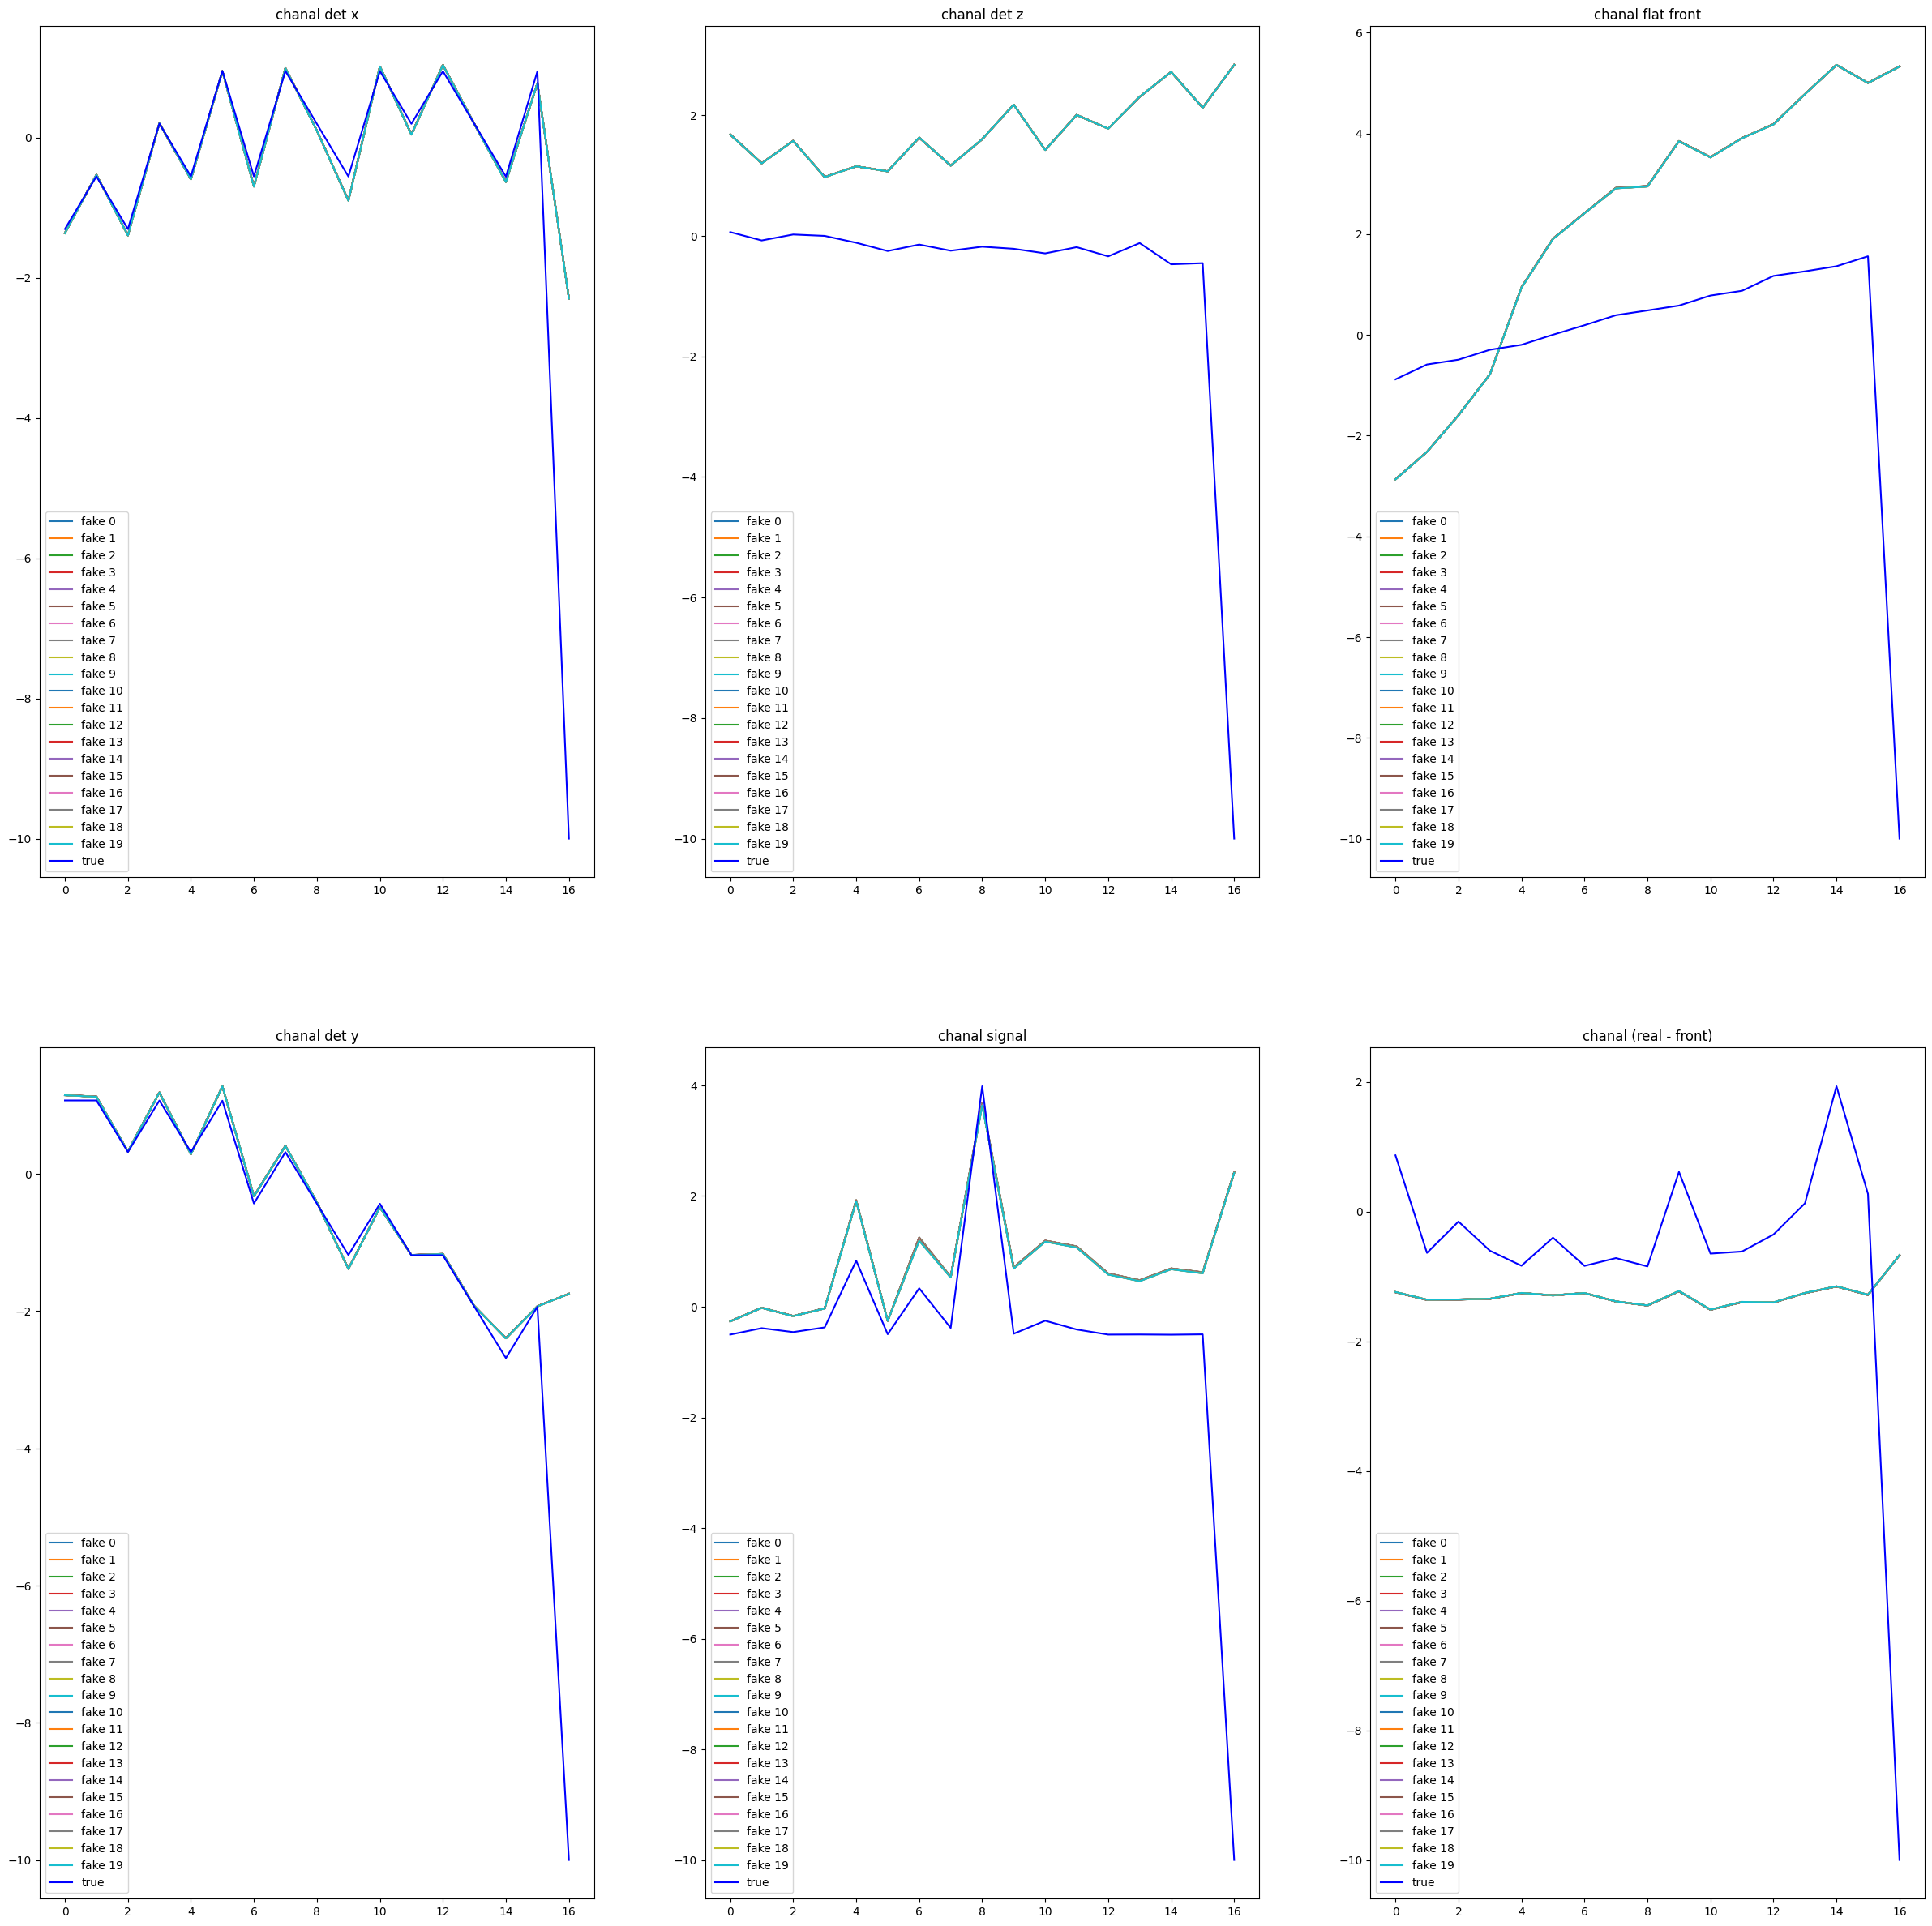

In [27]:
i=60
results = change_dims(x[i:i+1], 14)
show_data_many(x[i], [r[0] for r in results],lenght=18)

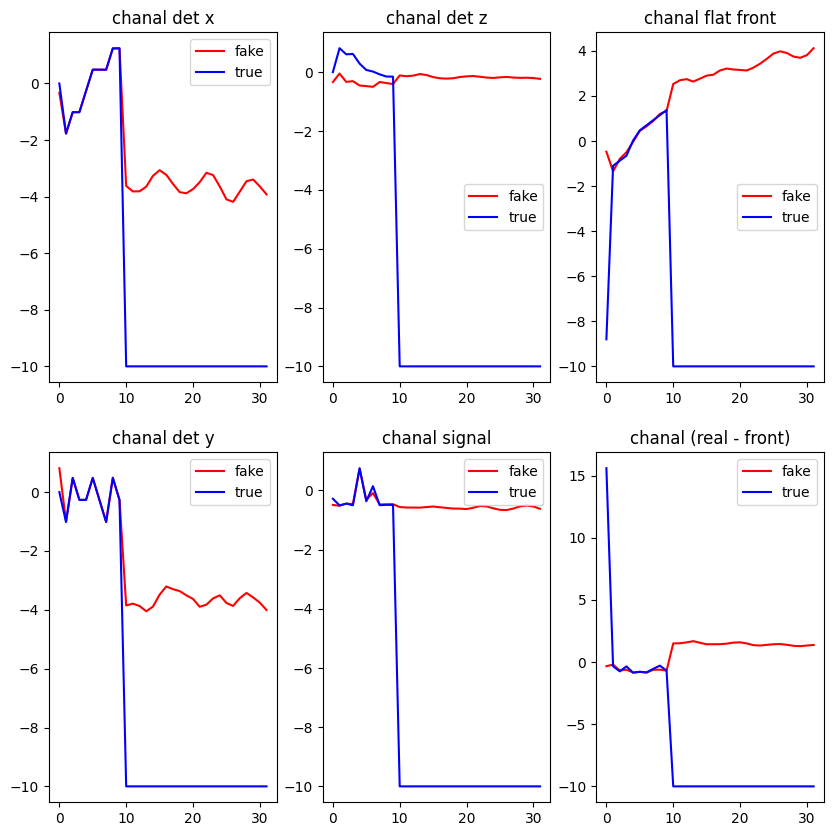

In [97]:
def run(data):
    # Правильная распаковка: encoder_model возвращает mu, log_var, (h_n, c_n)
    emb, _, (_, _) = encoder_model(data)
    # Извлекаем координаты из исходных данных (первые 3 канала: det x, det y, det z)
    x_coordinat = data[:,:,:3]
    # Получаем реальную длину последовательности
    seq_len = data.size(1)
    # decoder_model возвращает decoder_outputs, (None,None), num, recon_pred
    # Передаем координаты из исходных данных в декодер
    recon, (_,_), num, _ = decoder_model(emb, seq_len, x_coordinat)
    return recon
i=81
recon = run(x[i:i+1])
fig, axs = plt.subplots(2,3, figsize = (10,10))
names = ['det x', 'det y', 'det z', 'signal', 'flat front', '(real - front)']
for j in range(6):
    row = j%2
    col = j//2
    axs[row][col].plot(recon[0].to('cpu').detach().numpy()[:,j], 'r')
    # Исправлено: используем правильный индекс i вместо 0
    axs[row][col].plot(x[i].to('cpu').detach().numpy()[:,j], 'b')
    axs[row][col].legend(['fake', 'true'])
    axs[row][col].set_title(f'chanal {names[j]}')
    axs

In [95]:

def run_VAE(data):
    VAE_model = VAE.to('cuda:0')
    VAE_model.load_state_dict(VAE_state_dict)
    VAE_model.eval()
    recon = VAE_model(data)
    return recon




In [96]:
run_VAE(x[0:1])

AttributeError: 'str' object has no attribute '_apply'